In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: improve plot appearance
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/raw/final_processed_reviews.csv")

In [3]:
df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,cleaned_review,identified_theme
0,IT'S NOT WORK ON HUAWEI DEVICES,4,2026-05-15,CBE,Google Play,negative,0.999691,work huawei device,General Experience
1,wow,4,2026-05-14,CBE,Google Play,positive,0.999592,wow,General Experience
2,nice app,5,2026-05-14,CBE,Google Play,positive,0.999806,nice app,General Experience
3,formative,5,2026-05-14,CBE,Google Play,positive,0.998885,formative,General Experience
4,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,positive,0.996808,good app financial activity,General Experience


In [5]:
df['sentiment_label'].value_counts()

sentiment_label
positive    918
negative    573
neutral       9
Name: count, dtype: int64

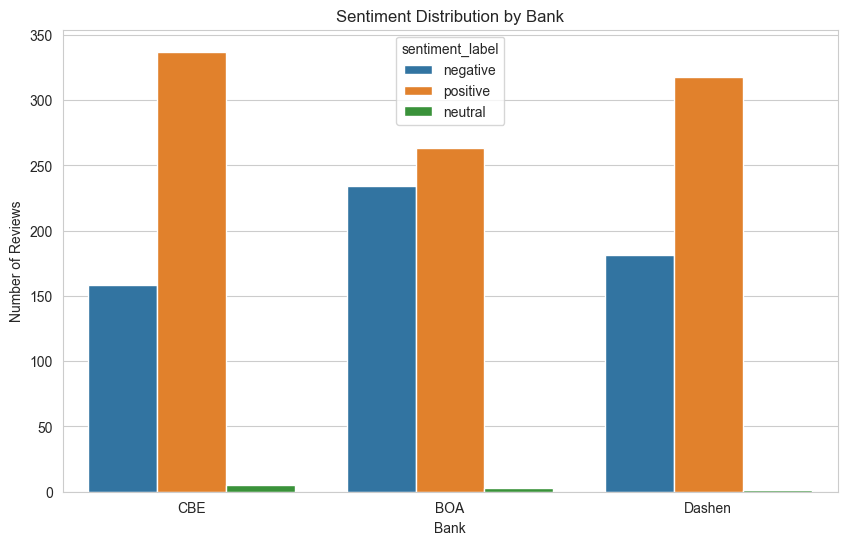

In [6]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='bank',
    hue='sentiment_label'
)

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")

plt.show()

In [7]:
average_rating = df.groupby('bank')['rating'].mean()

print(average_rating)

bank
BOA       3.566
CBE       4.134
Dashen    3.920
Name: rating, dtype: float64


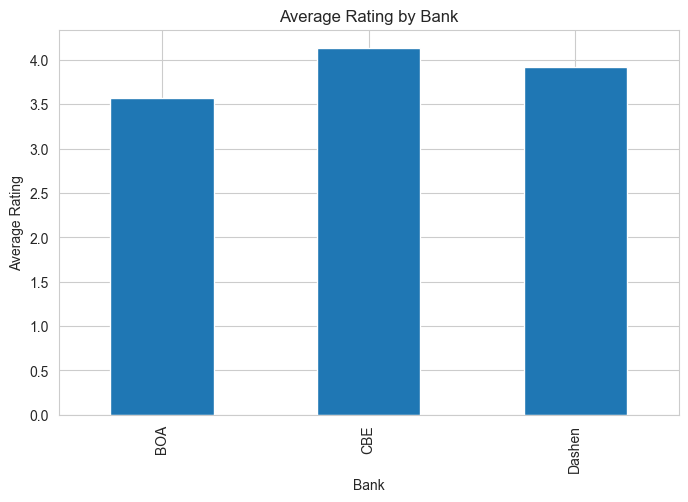

In [8]:
average_rating.plot(kind='bar', figsize=(8,5))

plt.title("Average Rating by Bank")
plt.xlabel("Bank")
plt.ylabel("Average Rating")

plt.show()

In [9]:
theme_counts = df['identified_theme'].value_counts()

print(theme_counts)

identified_theme
General Experience         1217
Transaction Performance     100
Feature Requests             64
Customer Support             47
Account Access Issues        47
UI & Design                  25
Name: count, dtype: int64


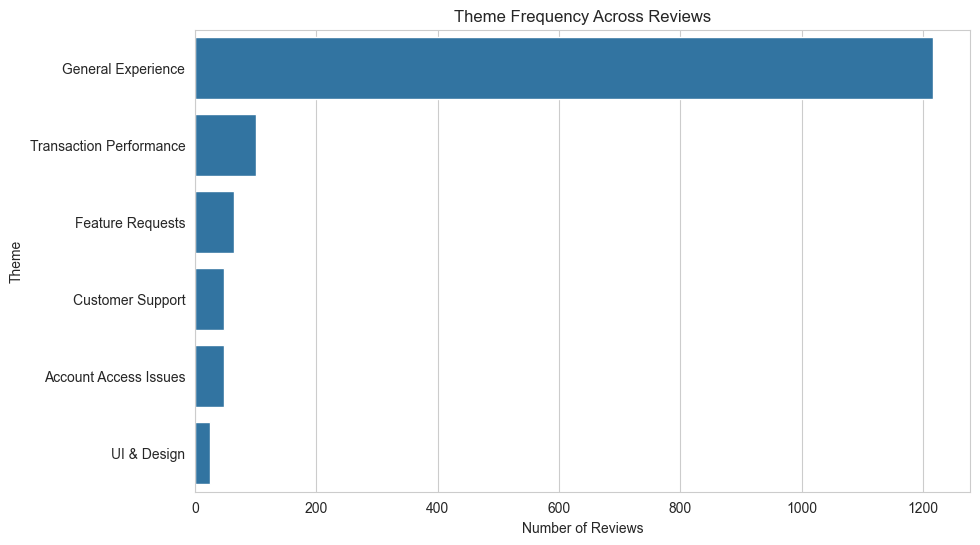

In [10]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='identified_theme',
    order=df['identified_theme'].value_counts().index
)

plt.title("Theme Frequency Across Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Theme")

plt.show()

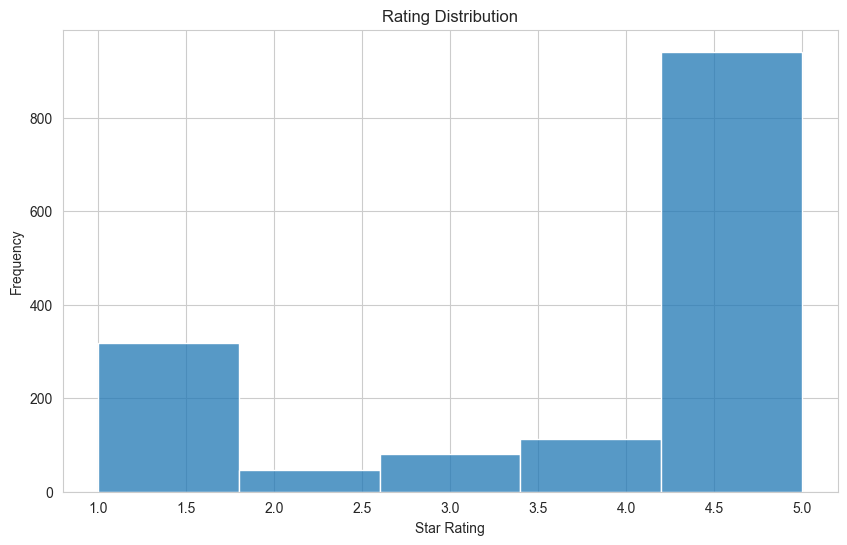

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='rating',
    bins=5
)

plt.title("Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Frequency")

plt.show()

In [12]:
df['date'] = pd.to_datetime(df['date'])

In [13]:
trend = df.groupby(
    [df['date'].dt.date, 'sentiment_label']
).size().unstack(fill_value=0)

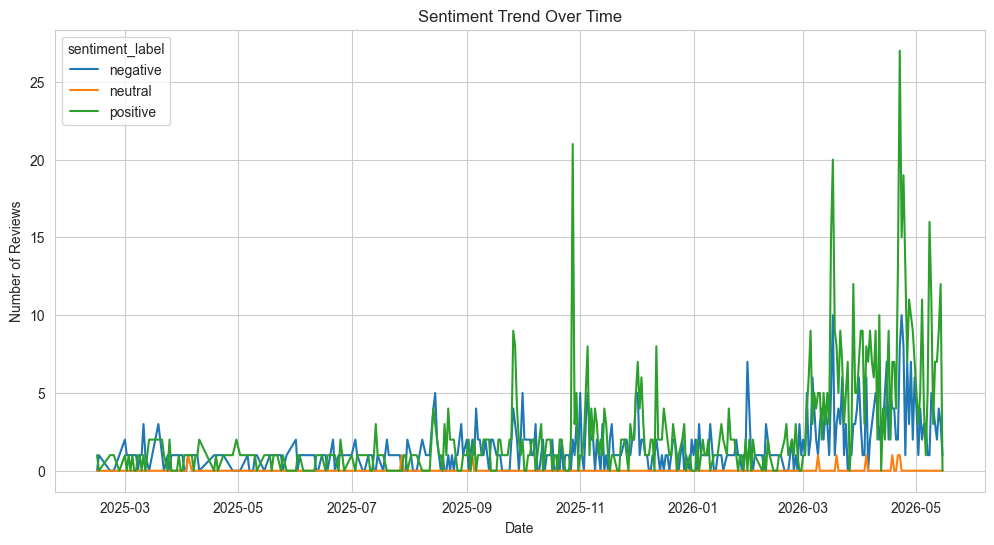

In [14]:
trend.plot(figsize=(12,6))

plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.show()

In [15]:
positive_reviews = df[df['sentiment_label'] == 'positive']

positive_reviews[['review', 'identified_theme']].head(20)

,review,identified_theme
1,wow,General Experience
2,nice app,General Experience
3,formative,General Experience
4,best app for financial activities 🙌,General Experience
6,incredible,General Experience
7,best app for financial sector,General Experience
8,it's a good application,General Experience
9,thank you cbe,General Experience
10,is good,General Experience
11,wow,General Experience


In [16]:
negative_reviews = df[df['sentiment_label'] == 'negative']

negative_reviews[['review', 'identified_theme']].head(20)

,review,identified_theme
0,IT'S NOT WORK ON HUAWEI DEVICES,General Experience
5,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,General Experience
13,"Nice, but I can't get some recently transactio...",Transaction Performance
14,Very Secure but very poor interface and limite...,UI & Design
24,why is my transaction fee hidden? Why doesn't ...,Transaction Performance
25,Gal✅😶‍🌫️,General Experience
27,እ. በ. ጥ. ነው,General Experience
30,this app is so functional for airtime for wall...,General Experience
33,There is a a problem when updating the app,Feature Requests
39,Internet Based mobile app for CBEBirr A Intern...,General Experience


In [17]:
comparison = df.groupby('bank').agg({
    'rating':'mean',
    'sentiment_score':'mean'
})

print(comparison)

        rating  sentiment_score
bank                           
BOA      3.566         0.966775
CBE      4.134         0.977637
Dashen   3.920         0.975573


In [19]:
import os

os.makedirs("../reports", exist_ok=True)

In [18]:
plt.savefig("../reports/sentiment_distribution.png")

FileNotFoundError: [Errno 2] No such file or directory: '../reports/sentiment_distribution.png'

<Figure size 640x480 with 0 Axes>